# Airbnb Price Analysis (NYC 2019)

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project analyses Airbnb listings in New York City from 2019. It examines how price varies by neighbourhood, room type, availability, and review activity. The insights help understand the short‑term rental market and can inform pricing strategies.

## Dataset
- **Source:** Kaggle – Airbnb NYC 2019
- **Rows:** 48,895 listings
- **Columns:** neighbourhood_group, neighbourhood, room_type, price, minimum_nights, number_of_reviews, availability_365, latitude, longitude

## Key Steps
1. Data cleaning (remove zero/negative prices, outliers)
2. Explore price distributions
3. Compare neighbourhood groups and room types
4. Analyse relationships between price, reviews, and availability
5. Visualise geographic price hotspots

## Requirements
- pandas, matplotlib, seaborn, numpy

---

**© 2026 Ibrahim – NYC Airbnb market analysis.**

### Install & Imports

In [1]:
!pip install -q pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [3]:
# Load from URL (or upload manually)
data = "/content/Airbnb NYC 2019 dataset.csv"
df = pd.read_csv(data)

print("Dataset shape:", df.shape)
df.head(2)

Dataset shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355


### Data Cleaning


In [4]:
# Remove rows with zero or negative price
df = df[df['price'] > 0]

# Cap price at 99th percentile to remove extreme outliers
price_99 = df['price'].quantile(0.99)
df = df[df['price'] <= price_99]

# Drop rows with missing crucial fields
df = df.dropna(subset=['neighbourhood_group', 'room_type', 'price'])

print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 48410


### Price Distribution

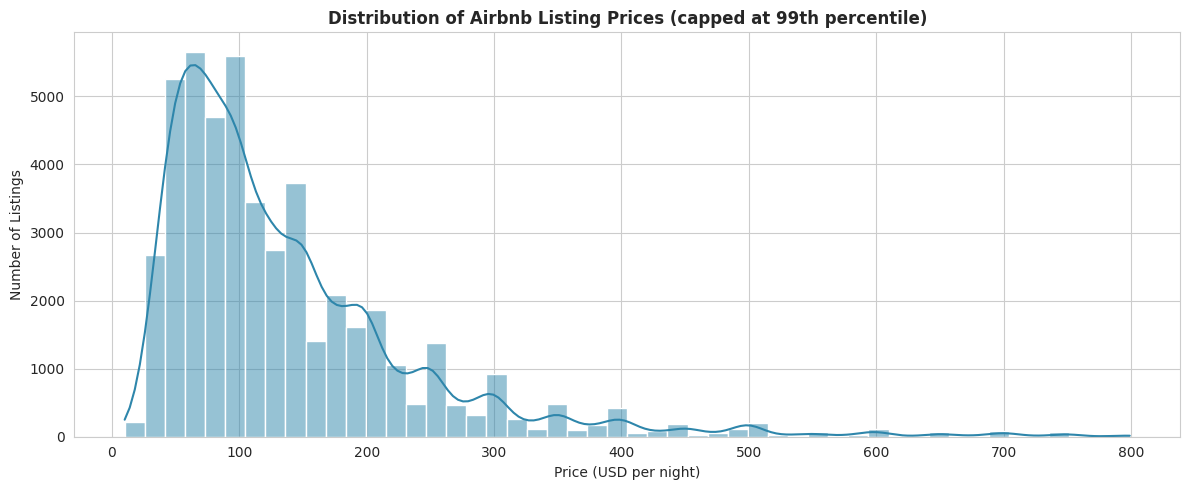

In [5]:
plt.figure(figsize=(12, 5))
sns.histplot(df['price'], bins=50, kde=True, color='#2E86AB')
plt.xlabel('Price (USD per night)')
plt.ylabel('Number of Listings')
plt.title('Distribution of Airbnb Listing Prices (capped at 99th percentile)', fontweight='bold')
plt.tight_layout()
plt.show()

### Average Price by Neighbourhood Group

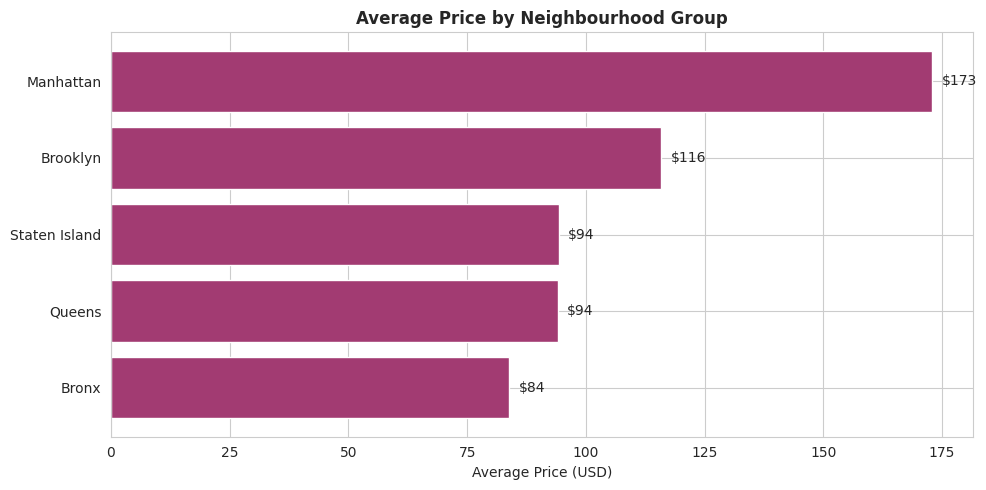

In [6]:
group_price = df.groupby('neighbourhood_group')['price'].mean().sort_values()

plt.figure(figsize=(10, 5))
bars = plt.barh(group_price.index, group_price.values, color='#A23B72')
plt.xlabel('Average Price (USD)')
plt.title('Average Price by Neighbourhood Group', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2, f'${width:.0f}', va='center')
plt.tight_layout()
plt.show()

### Average Price by Room Type

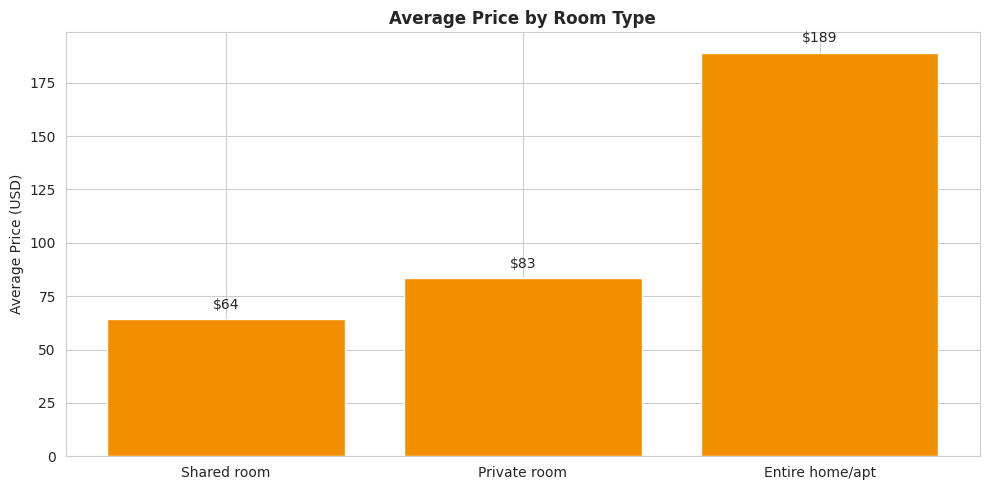

In [7]:
room_price = df.groupby('room_type')['price'].mean().sort_values()

plt.figure(figsize=(10, 5))
bars = plt.bar(room_price.index, room_price.values, color='#F18F01')
plt.ylabel('Average Price (USD)')
plt.title('Average Price by Room Type', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'${height:.0f}', ha='center')
plt.tight_layout()
plt.show()

### Price vs Number of Reviews (Scatter)

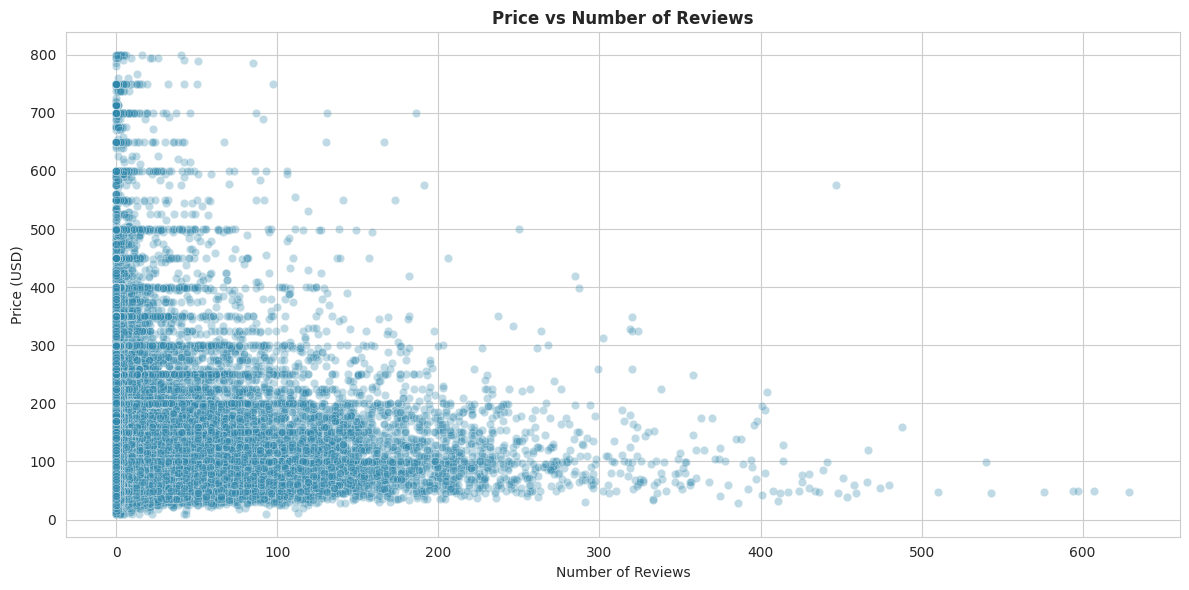

In [8]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='number_of_reviews', y='price', alpha=0.3, color='#2E86AB')
plt.xlabel('Number of Reviews')
plt.ylabel('Price (USD)')
plt.title('Price vs Number of Reviews', fontweight='bold')
plt.tight_layout()
plt.show()

### Availability vs Price (Box Plot)

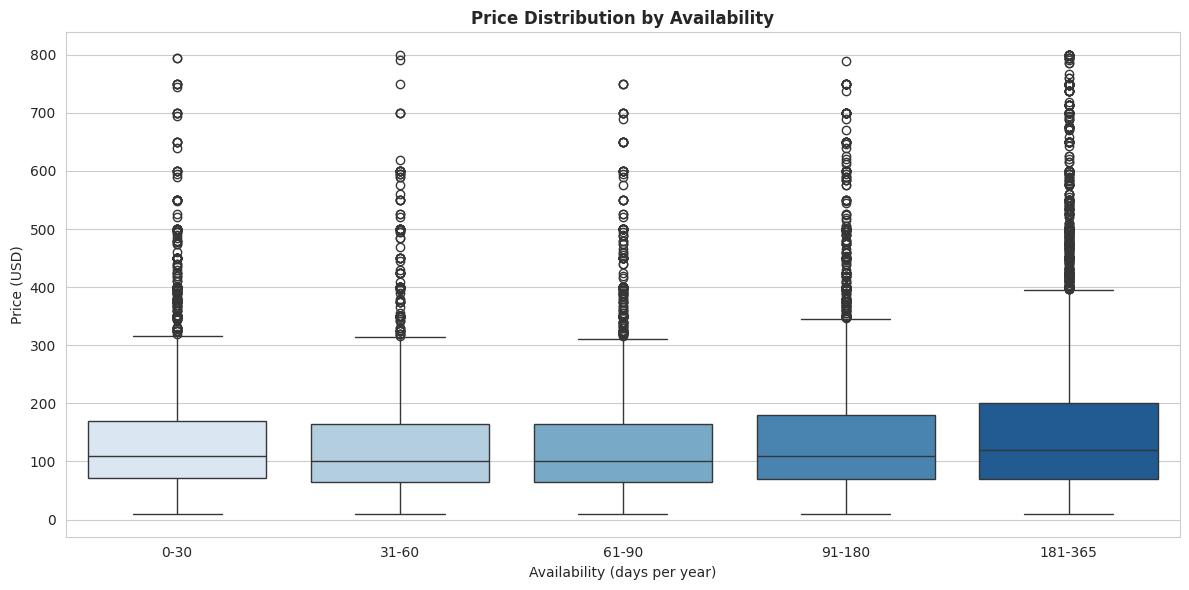

In [9]:
# Create availability bins
df['availability_bin'] = pd.cut(df['availability_365'], bins=[0, 30, 60, 90, 180, 365], labels=['0-30', '31-60', '61-90', '91-180', '181-365'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='availability_bin', y='price', palette='Blues')
plt.xlabel('Availability (days per year)')
plt.ylabel('Price (USD)')
plt.title('Price Distribution by Availability', fontweight='bold')
plt.tight_layout()
plt.show()

### Minimum Nights vs Price (Box Plot)

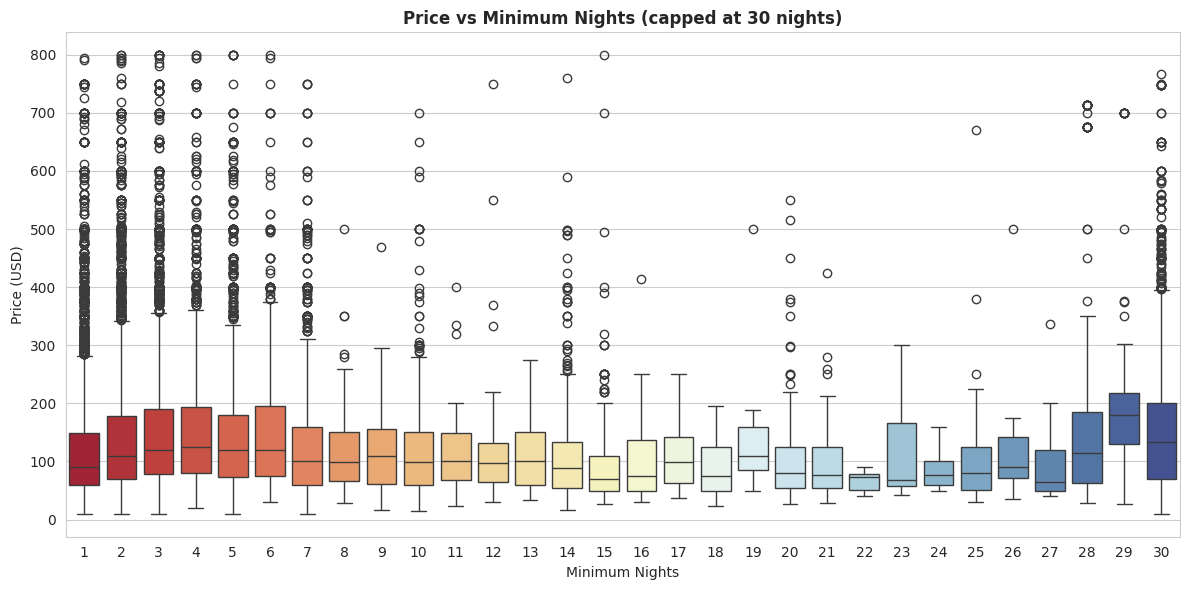

In [10]:
# Cap minimum_nights at 30 for readability
df_min = df[df['minimum_nights'] <= 30]
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_min, x='minimum_nights', y='price', palette='RdYlBu')
plt.xlabel('Minimum Nights')
plt.ylabel('Price (USD)')
plt.title('Price vs Minimum Nights (capped at 30 nights)', fontweight='bold')
plt.tight_layout()
plt.show()

### Top 10 Most Expensive Neighbourhoods

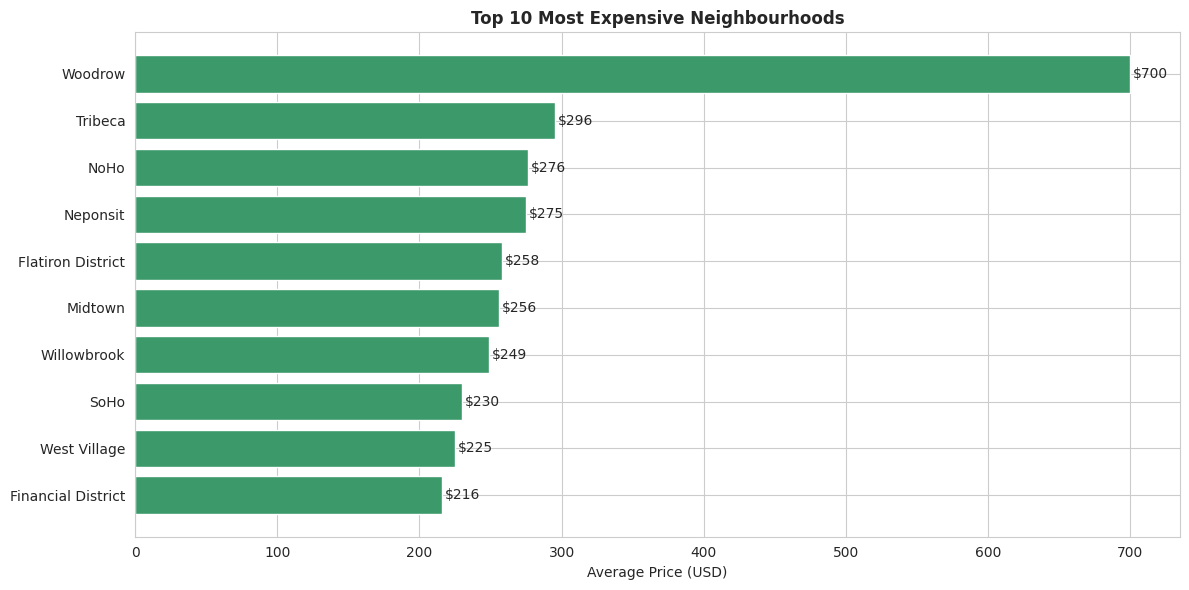

In [11]:
neigh_price = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(neigh_price.index[::-1], neigh_price.values[::-1], color='#3C9A6A')
plt.xlabel('Average Price (USD)')
plt.title('Top 10 Most Expensive Neighbourhoods', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2, f'${width:.0f}', va='center')
plt.tight_layout()
plt.show()

### Price Density by Neighbourhood Group (Violin Plot)

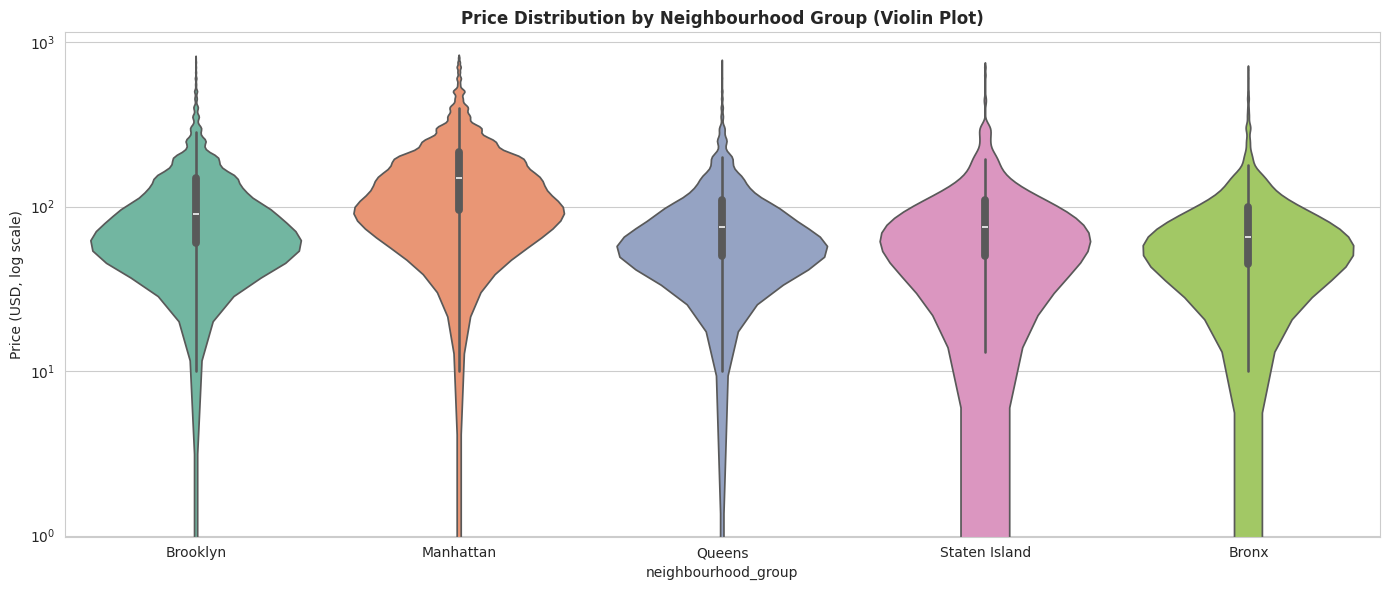

In [12]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='neighbourhood_group', y='price', palette='Set2')
plt.yscale('log')
plt.ylabel('Price (USD, log scale)')
plt.title('Price Distribution by Neighbourhood Group (Violin Plot)', fontweight='bold')
plt.tight_layout()
plt.show()

### Geospatial Price Heatmap (Scatter)

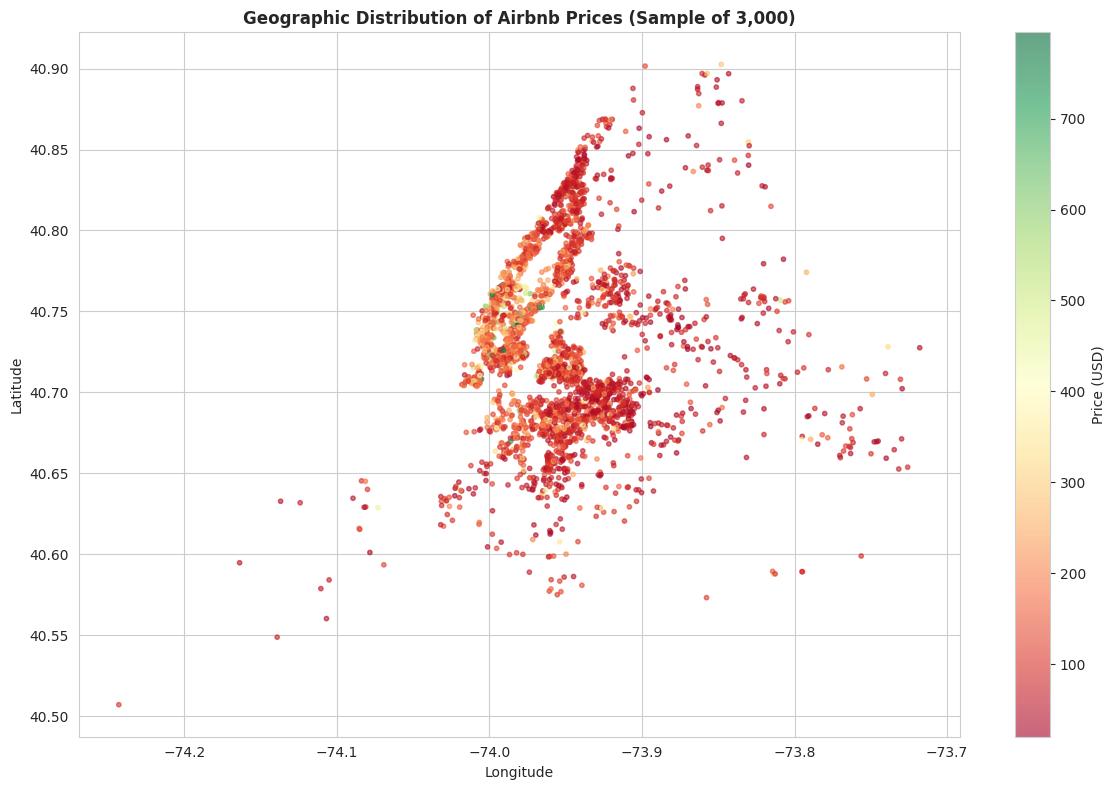

In [13]:
# Sample 3000 points for clarity
geo_sample = df.sample(n=3000, random_state=42)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(geo_sample['longitude'], geo_sample['latitude'], c=geo_sample['price'], cmap='RdYlGn', s=10, alpha=0.6)
plt.colorbar(scatter, label='Price (USD)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Airbnb Prices (Sample of 3,000)', fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap

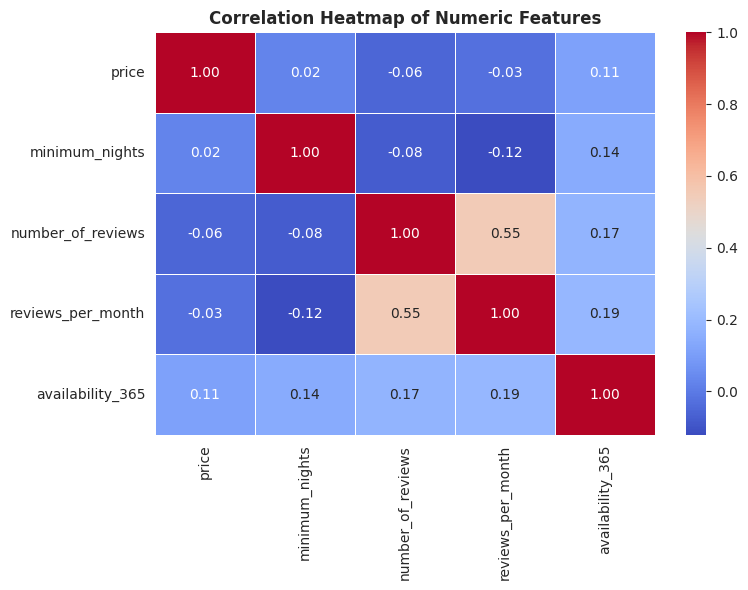

In [14]:
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights Summary

In [15]:
print(" Key Insights from Airbnb NYC Analysis")
print(f" Total listings analysed: {len(df):,}")
print(f" Median price per night: ${df['price'].median():.2f}")
print(f" Most expensive neighbourhood: {neigh_price.index[0]} (${neigh_price.iloc[0]:.0f})")
print(f" Room type with highest avg price: {room_price.idxmax()} (${room_price.max():.0f})")
print(f" Most popular availability: {df['availability_bin'].mode()[0]} days/year")
print(" Insights for travellers and hosts.")

 Key Insights from Airbnb NYC Analysis
 Total listings analysed: 48,410
 Median price per night: $105.00
 Most expensive neighbourhood: Woodrow ($700)
 Room type with highest avg price: Entire home/apt ($189)
 Most popular availability: 181-365 days/year
 Insights for travellers and hosts.


### Final Summary

In [16]:
print("Airbnb Price Analysis - COMPLETED")
print("Author: Ibrahim")
print("Dataset cleaned and explored.")
print("Price patterns by location, room type, and availability identified.")
print("Ready for presentation or further modelling.")

Airbnb Price Analysis - COMPLETED
Author: Ibrahim
Dataset cleaned and explored.
Price patterns by location, room type, and availability identified.
Ready for presentation or further modelling.
